In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, PoissonRegressor, ElasticNet
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler




In [ ]:
#!pip install sagemaker --upgrade

In [3]:
revenue=pd.read_csv('data/AccountRevenue.csv',skiprows=1)
if revenue.columns[0].startswith('Unnamed'):
    revenue=revenue.iloc[:,1:]

In [4]:
revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            836 non-null    object
 1   accountId     836 non-null    object
 2   createdAt     836 non-null    object
 3   updatedAt     836 non-null    object
 4   expenses      836 non-null    int64 
 5   grossProfit   836 non-null    int64 
 6   grossRevenue  836 non-null    int64 
 7   netProfit     836 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 52.4+ KB


In [5]:
revenue.head()


,id,accountId,createdAt,updatedAt,expenses,grossProfit,grossRevenue,netProfit
0,01J9WS55DN3C0SK0MZSAAW5W0T,01J5ZX1CP0EM2Y7YD9E1XNBGZ4,2024-10-11 03:15:02.712,2024-10-11 03:15:02.712,493731,940452,980952,155121
1,01JA9N573JDNYVH1YACGGPGPW0,01J5ZX1CP0EM2Y7YD9E1XNBGZ4,2024-10-16 03:15:17.747,2024-10-16 03:15:17.747,493731,940452,980952,155121
2,01JA9N57AB4AZXFDTF73X9YNK4,01J5ZX1CP0EM2Y7YD9E1XNBGZ4,2024-10-16 03:15:17.964,2024-10-16 03:15:17.964,493731,940452,980952,155121
3,01JAHCB9F9HW4RPV56WAT3M41Y,01J5ZX1CP0EM2Y7YD9E1XNBGZ4,2024-10-19 03:15:15.055,2024-10-19 03:15:15.055,4539100,15542653,17103545,11003553
4,01JAHCBAP0ERTFSRE9QZYXZFJ4,01J5ZX1CP0EM2Y7YD9E1XNBGZ4,2024-10-19 03:15:16.289,2024-10-19 03:15:16.289,4539100,15542653,17103545,11003553


In [6]:
#first delete where revenue=0
revenue_a = revenue[(revenue['grossRevenue']!=0) & (revenue['expenses']!=0)]
#revenue_a.info()

In [7]:
import random
random.seed(100)
noise_exp = np.random.uniform(-0.05, 0.05, size=len(revenue_a))
noise_rev= np.random.uniform(-0.05, 0.05, size=len(revenue_a))
noise_gprof= np.random.uniform(-0.05, 0.05, size=len(revenue_a))
noise_nprof= np.random.uniform(-0.05, 0.05, size=len(revenue_a))


revenue_a['exp'] = revenue_a['expenses'] * (1 + noise_exp)

revenue_a['rev'] = revenue_a['grossRevenue'] * (1 + noise_rev)
revenue_a['gprof'] = revenue_a['grossProfit'] * (1 + noise_gprof)
revenue_a['nprof'] = revenue_a['netProfit'] * (1 + noise_nprof)


/var/folders/28/sfh23ps14qg0ry2cn415y_ww0000gp/T/ipykernel_1689/1408399263.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revenue_a['exp'] = revenue_a['expenses'] * (1 + noise_exp)
/var/folders/28/sfh23ps14qg0ry2cn415y_ww0000gp/T/ipykernel_1689/1408399263.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revenue_a['rev'] = revenue_a['grossRevenue'] * (1 + noise_rev)
/var/folders/28/sfh23ps14qg0ry2cn415y_ww0000gp/T/ipykernel_1689/1408399263.py:12: SettingWithCopyWarning: 
A value is trying to be set 

In [8]:
revenue_a['exp'].value_counts()

exp
484065.583605    1
192480.857699    1
189412.851406    1
195187.042676    1
192112.614429    1
                ..
188681.787651    1
204509.805897    1
186255.861668    1
186083.464361    1
998340.705739    1
Name: count, Length: 563, dtype: int64

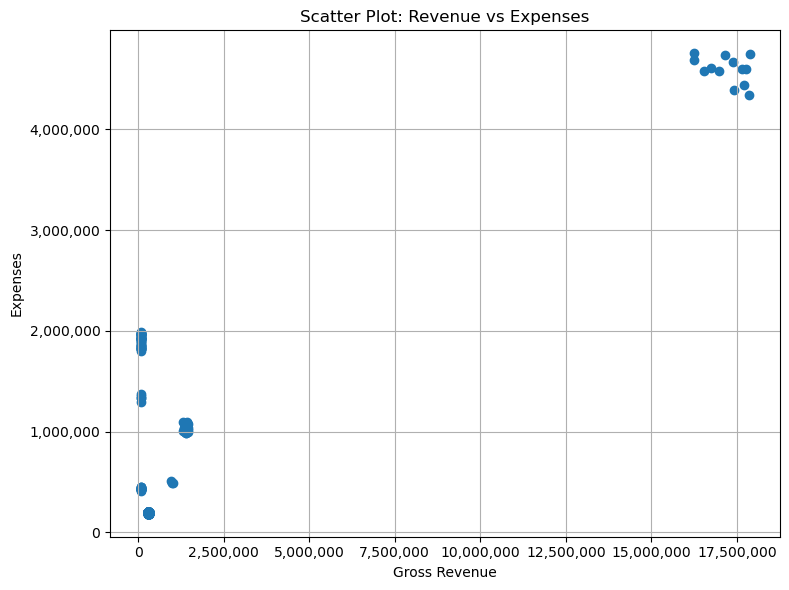

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Define formatter function
def comma_format(x, _):
    return f"{x:,.0f}"  # , adds commas; .0f = no decimals

plt.figure(figsize=(8, 6))

# Plot
plt.scatter(revenue_a["rev"], revenue_a["exp"])
plt.ylabel("Expenses")
plt.xlabel("Gross Revenue")
plt.title("Scatter Plot: Revenue vs Expenses")

# Apply comma formatter to both axes
ax = plt.gca()  # get current axis
ax.xaxis.set_major_formatter(FuncFormatter(comma_format))
ax.yaxis.set_major_formatter(FuncFormatter(comma_format))

plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
revenue_a['exp'].mean()

In [9]:
X=revenue_a[['rev','gprof','nprof']]

In [10]:
y=revenue_a['exp']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

In [16]:
X_train.head()

,rev,gprof,nprof
61,77963.211299,-17036.074833,-1.971364e+06
462,301836.754677,-17428.907938,-2.037502e+05
674,309327.346752,-16801.006542,-2.222777e+05
563,282774.819157,-17182.026402,-2.132187e+05
763,292164.325025,-17588.616200,-2.203036e+05


In [13]:
scaler=StandardScaler()

In [14]:
X_train_scaled=scaler.fit_transform(X_train)

In [15]:
X_test_scaled=scaler.fit_transform(X_test)

In [ ]:
# --- 4. Define models ---


models={
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet':  ElasticNet(alpha=1.0,l1_ratio=0.5)
}



In [ ]:
results=[]
for name, model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    #res=y_test-y_pred
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test, y_pred)
    coefs=model.coef_

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Coefficients': dict(zip(X, coefs))
    })
    
    

In [ ]:
results

In [ ]:
results_df = pd.DataFrame(results)
from IPython.display import display
display(results_df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Build metric DataFrame
metric_df = pd.DataFrame(results)[['Model', 'MAE', 'RMSE', 'R2']].set_index('Model')

# Build coefficient DataFrame
coef_df = pd.DataFrame({r['Model']: r['Coefficients'] for r in results}).T

# --- Plot 1: Metrics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    axes[i].bar(metric_df.index, metric_df[metric], color='skyblue')
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(metric_df.index)))
    axes[i].set_xticklabels(metric_df.index)

plt.tight_layout()
plt.show()

# --- Plot 2: Coefficients ---
coef_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Coefficients by Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=0)
plt.legend(title='Feature')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np


# Define RMSE scoring
#rmse_scorer = make_scorer(neg_mean_absolute_error, squared=False)

cv_results = []

for name, model in models.items():
    # call cross_val_score with the correct string scorer
    mae_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error'
    )
    # flip the sign to get positive MAE
    mean_mae = -mae_scores.mean()

    cv_results.append({
        'Model': name,
        'CV Mean MAE': mean_mae,
        'CV MAE (per fold)': -mae_scores
    })


In [ ]:
cv_df = pd.DataFrame(cv_results)
display(cv_df)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert cv_results (list of dicts) into a DataFrame for plotting
cv_plot_df = pd.DataFrame({
    result['Model']: result['CV MAE (per fold)']
    for result in cv_results
})

# Plot
plt.figure(figsize=(10, 6))
for model in cv_plot_df.columns:
    plt.plot(cv_plot_df.index, cv_plot_df[model], marker='o', label=model, alpha=0.5)

plt.title('Cross-Validation MAE per Fold')
plt.xlabel('Fold')
plt.ylabel('Mean Absolute Error')
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
revenue_a['exp'].mean()

In [17]:
#ok time to do gridsearch
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [18]:
#so i want to define my models, ill look at Ridge, Lasso, and Elastic Net.
#in Ridge i have my alpha parameters and the solver that is used to fit the model, in lasso i have my alpha paramenters, in Elastic Net, i have alpha and l1 ratios
#if there are challengs with convergence, then can add more parameters

#define parameter grid
param_grid={
    'Ridge':{
        'model__alpha':[0.001, 0.01, 0.1, 1, 10, 100]
    },
    'Lasso':{
        'model__alpha':[0.001, 0.01, 0.1, 1, 10, 100]
    },
    'ElasticNet':{
        'model__alpha':[0.001, 0.01, 0.1, 1, 10, 100],
        'model__l1_ratio':[0.1,0.33,0.5,0.9]
    }
}

models={
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'ElasticNet':ElasticNet()
}


In [19]:
grids = {}             # ⬅️ store each model’s GridSearchCV
grid_summaries = []    # ⬅️ summary table as before

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    grid = GridSearchCV(pipe,
                        param_grid[name],
                        cv=5,
                        scoring='neg_mean_absolute_error')
    grid.fit(X_train, y_train)
    
    grids[name] = grid
    grid_summaries.append({
      'Model': name,
      'Best Params': grid.best_params_,
      'CV MAE': -grid.best_score_
    })

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.646e+12, tolerance: 2.019e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.211e+12, tolerance: 1.957e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+12, toler

In [20]:
pipeline=Pipeline

In [21]:

from matplotlib.ticker import ScalarFormatter
# Pull out the ridge GridSearchCV
ridge_grid = grids['Ridge']

# Turn cv_results_ into a DataFrame
df = pd.DataFrame(ridge_grid.cv_results_)

# Convert scores to positive MAE
df['MAE'] = -df['mean_test_score']

# Extract the alpha values (they’re stored under 'param_model__alpha')
df['alpha'] = df['param_model__alpha'].astype(float)

# Sort by alpha so the plot is clean
df = df.sort_values('alpha')

# — Plot —
plt.figure(figsize=(8, 5))
plt.plot(df['alpha'], df['MAE'], marker='o')
plt.xscale('log')                         # alphas are usually on a log scale
plt.xlabel('alpha (Ridge regularization strength)')
plt.ylabel('Cross-Validated MAE')
plt.title('Ridge: α vs. CV MAE')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:

from matplotlib.ticker import ScalarFormatter
# Pull out the ridge GridSearchCV
lasso_grid = grids['Lasso']

# Turn cv_results_ into a DataFrame
df = pd.DataFrame(lasso_grid.cv_results_)

# Convert scores to positive MAE
df['MAE'] = -df['mean_test_score']

# Extract the alpha values (they’re stored under 'param_model__alpha')
df['alpha'] = df['param_model__alpha'].astype(float)

# Sort by alpha so the plot is clean
df = df.sort_values('alpha')

# — Plot —
plt.figure(figsize=(8, 5))
plt.plot(df['alpha'], df['MAE'], marker='o')
plt.xscale('log')                         # alphas are usually on a log scale
plt.xlabel('alpha (Lasso regularization strength)')
plt.ylabel('Cross-Validated MAE')
plt.title('Lasso: α vs. CV MAE')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Lasso: alpha vs CV MAE


# ElasticNet: faceted by l1_ratio
enet_grid = grids['ElasticNet']
enet_df = pd.DataFrame(enet_grid.cv_results_)
enet_df['MAE'] = -enet_df['mean_test_score']
enet_df['alpha'] = enet_df['param_model__alpha'].astype(float)
enet_df['l1_ratio'] = enet_df['param_model__l1_ratio'].astype(float)

for ratio in sorted(enet_df['l1_ratio'].unique()):
    sub_df = enet_df[enet_df['l1_ratio'] == ratio].sort_values('alpha')
    plt.figure(figsize=(5, 3))
    plt.plot(sub_df['alpha'], sub_df['MAE'], marker='o')
    plt.xscale('log')
    plt.xlabel('alpha (ElasticNet)')
    plt.ylabel('CV MAE')
    plt.title(f'ElasticNet: α vs CV MAE (l1_ratio={ratio})')
    plt.grid(True, which='both', ls='--', lw=0.5)
    plt.tight_layout()
    plt.show()

In [22]:
#ok so now we have the grid
grid_summaries

[{'Model': 'Ridge',
  'Best Params': {'model__alpha': 0.001},
  'CV MAE': 34333.37661143573},
 {'Model': 'Lasso',
  'Best Params': {'model__alpha': 0.001},
  'CV MAE': 34857.8272588854},
 {'Model': 'ElasticNet',
  'Best Params': {'model__alpha': 0.001, 'model__l1_ratio': 0.9},
  'CV MAE': 35017.5249016528}]

In [ ]:
#ok lets look at FORMALIZING the final stuff that we need to put into VS.
#we want our model parameters and the regularization stuff picked.
best_lasso = grids['Lasso'].best_estimator_


In [ ]:
best_lasso

In [ ]:
#ok so we have the best lasso.  Now what to put into 


# Pull model name with lowest CV MAE
lasso_summary = next(item for item in grid_summaries if item['Model'] == 'Lasso')
lasso_alpha = lasso_summary['Best Params']['model__alpha']

# Then from your GridSearchCV dictionary
best_lasso = grids['Lasso'].best_estimator_

In [ ]:
lasso_summary